# Assignment 1: Explainable AI for Protein Biology 

**Course:** Advanced Machine Learning for the Life Sciences (MBioAML)
**Dataset:** Extracellular Vesicle (EV) Protein Sorting
**Environment:** Google Colab (CPU runtime is sufficient)

---

## Overview

Machine learning models can predict complex biological outcomes — such as whether a protein is sorted into extracellular vesicles — with high accuracy. But in biology, prediction alone is not enough. We need to understand *why* a model makes a decision: which features drive the prediction, and does that align with known biology?

This assignment puts those ideas into practice. You will:

1. **Train** three models (Logistic Regression, Random Forest, MLP) on real protein biology data
2. **Visualize** global model behavior with PDP, ICE, ALE, and permutation importance
3. **Explain** individual predictions with **LIME** — and explore how its hyperparameters affect results
4. **Explain** with **SHAP** using model-agnostic methods (Sampling, Permutation, Kernel SHAP)
5. **Explain** with **model-specific SHAP** (TreeSHAP, DeepSHAP) and compare speed/reliability
6. **Reflect** on what each method reveals about the biology of EV protein sorting

---

## The Dataset: Extracellular Vesicle Protein Sorting

Extracellular vesicles (EVs) are small membrane-bound particles released by cells. They carry proteins, lipids, and nucleic acids and play key roles in cell-to-cell communication, immune signalling, and even cancer metastasis. Understanding *which proteins* get sorted into EVs — and what makes them EV-destined — is a major open question in cell biology.

**Task:** Binary classification — predict whether a protein will be sorted into EVs (`EV = 1`) or not (`EV = 0`) from protein biochemical and bioinformatic features.

**Features (93 total) include:**
- Physicochemical properties: length, molecular weight, hydrophobicity, isoelectric point, charge, GRAVY index
- Amino acid composition (20 amino acid frequencies)
- Secondary structure fractions (helix, sheet, turn)
- Surface accessibility: total/relative accessible surface area, exposed residue fractions
- Post-translational modifications (PTMs): phosphorylation, ubiquitination, glycosylation, etc.
- Protein domain annotations: coiled-coil, transmembrane, EGF, RRM, etc.
- Solubility and aggregation propensity scores

---

## How to read this notebook

- **Explanatory cells** (like this one) introduce each concept and explain *why* we do things.
- **Code cells** contain the implementation — read them carefully before running.
- Cells marked with ✏️ **STUDENT TASK** require you to write code or answer questions.
- Questions marked **Q** should be answered directly in the notebook (add a markdown cell or use the provided answer box).

> ⚠️ **Colab note:** Run cells top-to-bottom. If your runtime disconnects, restart from Section 0.

---

## Table of Contents

| Section | Topic |
|---------|-------|
| [0. Setup](#setup) | Install packages, set seeds |
| [1. Data](#data) | Load, explore, and understand the EV dataset |
| [2. Models](#models) | Train Logistic Regression, Random Forest, MLP |
| [⬛ Day 1 Assignment](#day1) |----- |
| [3. Global Explanations](#global) | PDP, ICE, ALE, Permutation Importance |
| [4. LIME](#lime) | Local explanations, perturbations, kernel, fidelity, complexity |
| [5. SHAP Agnostic](#shap-ag) | Kernel SHAP and background sample effects |
| [6. SHAP Specific](#shap-sp) | TreeSHAP, DeepSHAP; speed & reliability vs Kernel SHAP |
| [7. Synthesis](#synthesis) | Compare methods, biological interpretation |


---
## Section 0: Setup & Installation <a id='setup'></a>

We install all required packages in one go.  It may take 1–2 minutes.

> **Why so many packages?** LIME and SHAP each come with their own dependencies. `torch` is needed for the MLP. `alibi` and `PyALE` provide ALE plots. `interpret` gives us PDP and ICE. `matplotlib` and `seaborn` for all visualization.


In [62]:
# ── 0.1  Install all required packages ───────────────────────────────────────
# Run this cell first. All output is suppressed for readability.
# If a package fails to install, remove the '> /dev/null 2>&1' and re-run to see the error.

!pip install -q numpy pandas "scikit-learn>=1.3" matplotlib seaborn > /dev/null 2>&1
!pip install -q torch > /dev/null 2>&1
!pip install -q lime > /dev/null 2>&1
!pip install -q shap > /dev/null 2>&1
!pip install -q PyALE > /dev/null 2>&1
!pip install -q tqdm joblib > /dev/null 2>&1

print("✅ All packages installed.")

298768.84s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298774.41s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298779.99s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298785.57s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298791.17s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
298796.76s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


✅ All packages installed.


In [1]:
# ── 0.2  Imports and global settings ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings, time, random, copy
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, RocCurveDisplay, confusion_matrix
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split

# LIME
from lime.lime_tabular import LimeTabularExplainer

# SHAP
import shap

print("✅ All imports successful.")

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

PyTorch device: cpu
✅ All imports successful.


---
## Section 1: Data Loading and Exploration <a id='data'></a>

### 1.1 Loading the data

We train on a large dataset of annotated proteins and evaluate on a held-out test set. The notebook now loads both files directly from this GitHub repository, so no manual upload step is needed when the repository is accessible from Colab.


In [2]:
# ── 1.1  Load train and test data directly from GitHub ───────────────────
GITHUB_OWNER = "Majeed7"
GITHUB_REPO = "MbioAML_Assignment"
GITHUB_BRANCH = "main"
DATA_SUBDIR = "train%3Atest"  # URL-encoded form of `train:test`

BASE_URL = f"https://raw.githubusercontent.com/{GITHUB_OWNER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATA_SUBDIR}"
train_url = f"{BASE_URL}/training_remaining.csv"
test_url = f"{BASE_URL}/test_Dhondt2021.csv"

train_df = pd.read_csv(train_url)
test_df  = pd.read_csv(test_url)

TARGET  = "EV"
ID_COL  = "id"
FEATURE_COLS = [c for c in train_df.columns if c not in [TARGET, ID_COL]]

X_train = train_df[FEATURE_COLS].values.astype(np.float32)
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].values.astype(np.float32)
y_test  = test_df[TARGET].values

print(f"Training set : {X_train.shape[0]:,} samples  |  {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Feature list (first 10): {FEATURE_COLS[:10]}")
print(f"Training URL : {train_url}")
print(f"Test URL     : {test_url}")


Training set : 13,331 samples  |  93 features
Test set     : 1,426 samples
Feature list (first 10): ['length', 'hydr_count', 'polar_count', 'molecular_weight', 'helix', 'turn', 'sheet', 'A', 'C', 'D']
Training URL : https://raw.githubusercontent.com/Majeed7/MbioAML_Assignment/main/train%3Atest/training_remaining.csv
Test URL     : https://raw.githubusercontent.com/Majeed7/MbioAML_Assignment/main/train%3Atest/test_Dhondt2021.csv


### 1.2 Class balance

Class imbalance is common in biology datasets. An imbalanced dataset means a model can appear to perform well simply by predicting the majority class. We must check the label distribution before trusting any accuracy number.


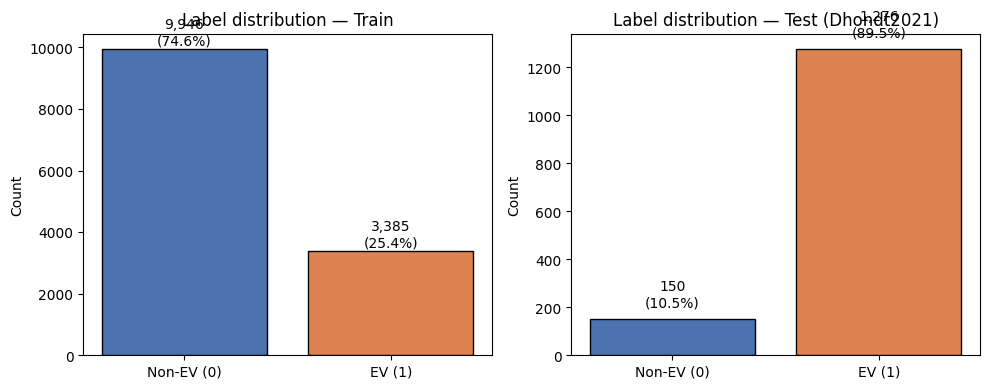

Train positive rate: 0.254
Test  positive rate: 0.895


In [ ]:
# ── 1.2  Class balance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (split_name, y) in zip(axes, [("Train", y_train), ("Test (Dhondt2021)", y_test)]):
    counts = np.bincount(y)
    bars = ax.bar(["Non-EV (0)", "EV (1)"], counts, color=["#4C72B0", "#DD8452"], edgecolor="black")
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                f"{cnt:,}\n({100*cnt/len(y):.1f}%)", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Label distribution — {split_name}", fontsize=12)
    ax.set_ylabel("Count")

plt.tight_layout()
## if you wanna save the figure, uncomment the line below. Otherwise, it will just be displayed.
# plt.savefig("class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")


**Q1.** Is the dataset balanced? How will class imbalance affect model training and evaluation? Which metric is most reliable when classes are imbalanced — accuracy, F1, or AUC? Explain your reasoning.

> *Your answer here*


### Section 1.3: Correlation of features

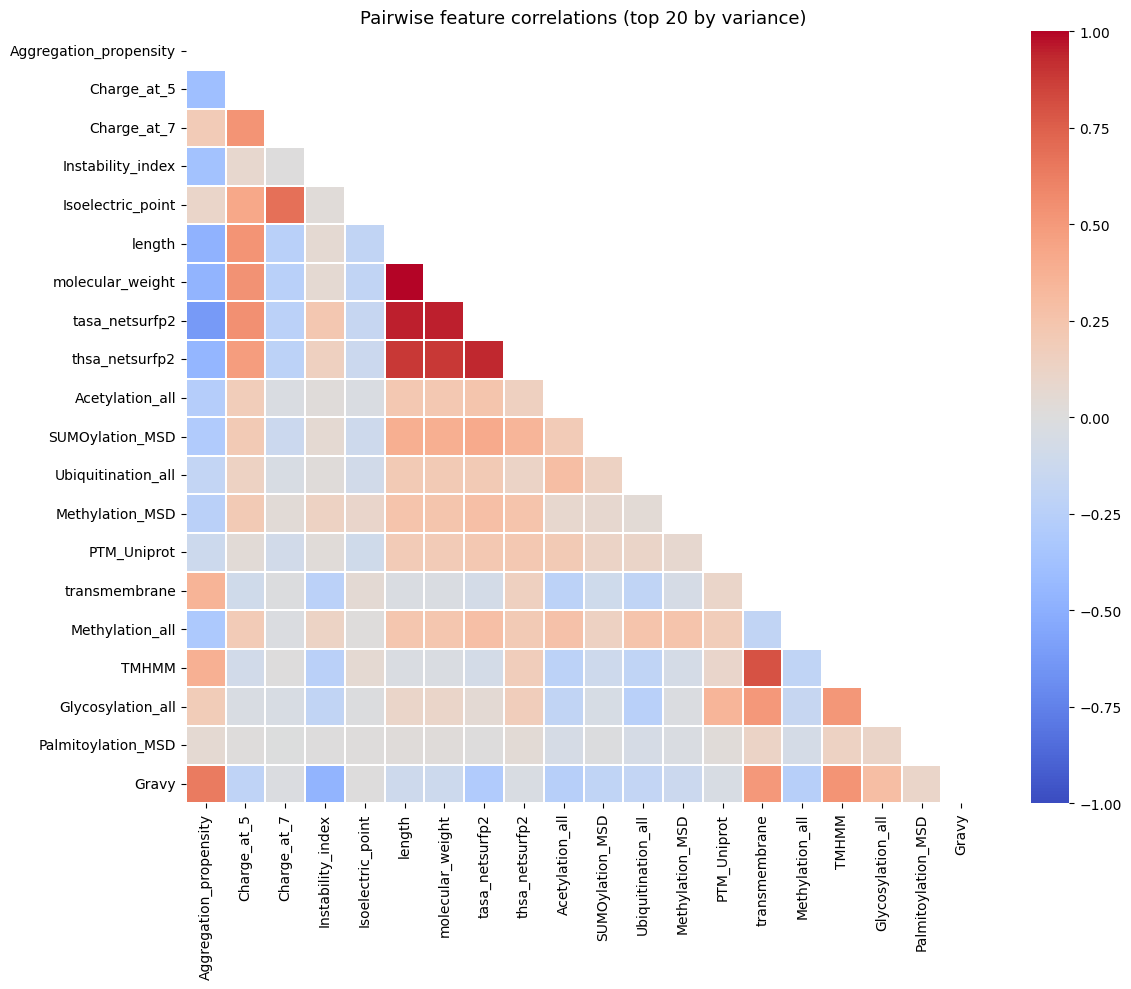

Highest absolute correlations:
molecular_weight        length                    0.999356
tasa_netsurfp2          length                    0.952216
molecular_weight        tasa_netsurfp2            0.950167
thsa_netsurfp2          tasa_netsurfp2            0.933299
length                  thsa_netsurfp2            0.889403
thsa_netsurfp2          molecular_weight          0.885359
transmembrane           TMHMM                     0.801779
Charge_at_7             Isoelectric_point         0.683621
Gravy                   Aggregation_propensity    0.639782
Aggregation_propensity  tasa_netsurfp2            0.618076


In [ ]:
# ── 1.4  Correlation heatmap (top 20 features by variance) ──────────────────
top_feat_idx = np.argsort(X_train.var(axis=0))[::-1][:20]
top_feat_names = [FEATURE_COLS[i] for i in top_feat_idx]
corr = pd.DataFrame(X_train[:, top_feat_idx], columns=top_feat_names).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pairwise feature correlations (top 20 by variance)", fontsize=13)
plt.tight_layout()
plt.savefig("feature_correlations.png", dpi=120, bbox_inches="tight")
plt.show()

print("Highest absolute correlations:")
corr_long = corr.abs().unstack().sort_values(ascending=False)
corr_long = corr_long[corr_long < 1.0].drop_duplicates()
print(corr_long.head(10).to_string())


---
## Section 2: Model Training <a id='models'></a>

We train three models of increasing complexity:

| Model | Why we use it |
|-------|--------------|
| **Logistic Regression** | giving probabilities; explaining the probabilities of the two classes |
| **Random Forest** | Non-linear ensemble; |
| **MLP (PyTorch)** | Deep network;  |

All models are trained on the same features and evaluated on the same test set. To incorporate class imbalance explicitly, we compute class weights from `y_train` and reuse those weights in Logistic Regression, Random Forest, and the MLP loss.



### 2.1 Logistic Regression
We train a logistic regression in this section. The training has not taken into account the class imbalance (and you need to take care of it!)

In [ ]:
# ── 2.1  Logistic Regression ──────────────────────────────────────────────────
# Compute class weights from the training split only.
class_counts = np.bincount(y_train)
class_weight_dict = {
    0: len(y_train) / (class_counts[0]),
    1: len(y_train) / (class_counts[1]),
}
print(f"Training class counts: Non-EV={class_counts[0]:,}, EV={class_counts[1]:,}")
print(f"Class weights used: {class_weight_dict}")

# We wrap with a StandardScaler — LR is sensitive to feature scale.
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        ### --------------------------------------------
        # Class imbalance should be taken care of here!
        ### --------------------------------------------
        C=0.4,          # regularization
        random_state=SEED
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

print("Logistic Regression — Test set performance")
print(f"  AUC  : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"  F1   : {f1_score(y_test, lr_preds):.4f}")
print(f"  Acc  : {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds, target_names=["Non-EV","EV"]))


Training class counts: Non-EV=9,946, EV=3,385
Class weights used: {0: np.float64(1.3403378242509552), 1: np.float64(3.9382570162481536)}
Logistic Regression — Test set performance
  AUC  : 0.8258
  F1   : 0.9125
  Acc  : 0.8485
              precision    recall  f1-score   support

      Non-EV       0.36      0.56      0.44       150
          EV       0.94      0.88      0.91      1276

    accuracy                           0.85      1426
   macro avg       0.65      0.72      0.67      1426
weighted avg       0.88      0.85      0.86      1426



**Q** Looking at the performance of Logistic Regression:
- How is it with respect to the Non-EV class (minority)?
- Can you understand how the classes should be weighted (`class_weight_dict`)?
- Does adding class weight help the classification? To what extend?

### 2.2 Random Forest


In [ ]:
# ── 2.2  Random Forest ───────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    ### --------------------------------------------
    # Class imbalance should be taken care of here!
    ### --------------------------------------------    
    max_features="sqrt",
    n_jobs=-1,
    random_state=SEED
)

rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("Random Forest — Test set performance")
print(f"  AUC  : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"  F1   : {f1_score(y_test, rf_preds):.4f}")
print(f"  Acc  : {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds, target_names=["Non-EV","EV"]))


Random Forest — Test set performance
  AUC  : 0.8330
  F1   : 0.8854
  Acc  : 0.8079
              precision    recall  f1-score   support

      Non-EV       0.30      0.63      0.41       150
          EV       0.95      0.83      0.89      1276

    accuracy                           0.81      1426
   macro avg       0.63      0.73      0.65      1426
weighted avg       0.88      0.81      0.84      1426



**Q** Compare the performance of random forest (with and without class weights) with logistic regression

### 2.3 MLP (PyTorch)

We build a small fully-connected network. The architecture is intentionally simple — three hidden layers with ReLU activations and dropout for regularization. We also build a **scikit-learn compatible wrapper** so that LIME (which expects a `predict_proba` function) can use this model without any modifications.

The class imbalance for MLP is taken care of with a proper loss


In [26]:
# ── 2.3a  MLP architecture ────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class EVNet(nn.Module):
    """
    Simple 3-layer MLP for EV protein classification.
    Output: single logit (apply sigmoid for probability).
    """
    def __init__(self, input_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            # nn.Linear(64, 32),
            # nn.ReLU(),
            # nn.Linear(32, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)   # shape: (B,)


INPUT_DIM = X_train.shape[1]
mlp = EVNet(INPUT_DIM).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP: {total_params:,} trainable parameters")
print(mlp)


MLP: 20,609 trainable parameters
EVNet(
  (net): Sequential(
    (0): Linear(in_features=93, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [27]:
# ── 2.3b  Preprocess: scale inputs ────────────────────────────────────────────
# The MLP shares the same scaler as Logistic Regression.
mlp_scaler = StandardScaler()
X_train_scaled = mlp_scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled  = mlp_scaler.transform(X_test).astype(np.float32)

# Use the same training-derived class imbalance information in the MLP loss.
pos_weight = torch.tensor([class_weight_dict[1] / class_weight_dict[0]], dtype=torch.float32).to(DEVICE)
print(f"MLP positive-class loss weight: {pos_weight.item():.3f}")

# Data loaders
train_tensor = TensorDataset(
    torch.tensor(X_train_scaled), torch.tensor(y_train, dtype=torch.float32))
test_tensor  = TensorDataset(
    torch.tensor(X_test_scaled),  torch.tensor(y_test,  dtype=torch.float32))

train_loader = DataLoader(train_tensor, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_tensor,  batch_size=512, shuffle=False)


MLP positive-class loss weight: 2.938


In [28]:
# ── 2.3c  Training loop ───────────────────────────────────────────────────────
def train_mlp(model, train_loader, n_epochs=30, lr=1e-3, pos_weight=None):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_loss = float("inf")
    best_state = None

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        epoch_loss /= len(train_loader)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 50 == 0:
            print(f"  Epoch {epoch:3d}/{n_epochs}  loss={epoch_loss:.4f}")

    model.load_state_dict(best_state)
    return model


print("Training MLP…")
mlp = train_mlp(mlp, train_loader, n_epochs=300, pos_weight=pos_weight)
print("Done.")


Training MLP…
  Epoch  50/300  loss=0.7145
  Epoch 100/300  loss=0.7153
  Epoch 150/300  loss=0.7148
  Epoch 200/300  loss=0.7142
  Epoch 250/300  loss=0.7149
  Epoch 300/300  loss=0.7159
Done.


**Q** Can you tell how class imbalance is take care of for this MLP model? 

In [29]:
# ── 2.3d  MLP evaluation + sklearn wrapper ────────────────────────────────────
def mlp_predict_proba(X: np.ndarray) -> np.ndarray:
    """
    sklearn-compatible predict_proba for the MLP.
    Accepts a raw (unscaled) numpy array, scales internally.
    Returns shape (N, 2): [P(non-EV), P(EV)].
    """
    X_sc = mlp_scaler.transform(X).astype(np.float32)
    with torch.no_grad():
        logits = mlp(torch.tensor(X_sc).to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
    return np.column_stack([1 - probs, probs])


mlp_probs = mlp_predict_proba(X_test)[:, 1]
mlp_preds = (mlp_probs >= 0.5).astype(int)

print("MLP — Test set performance")
print(f"  AUC  : {roc_auc_score(y_test, mlp_probs):.4f}")
print(f"  F1   : {f1_score(y_test, mlp_preds):.4f}")
print(f"  Acc  : {accuracy_score(y_test, mlp_preds):.4f}")
print(classification_report(y_test, mlp_preds, target_names=["Non-EV","EV"]))


MLP — Test set performance
  AUC  : 0.7912
  F1   : 0.6071
  Acc  : 0.4909
              precision    recall  f1-score   support

      Non-EV       0.16      0.93      0.28       150
          EV       0.98      0.44      0.61      1276

    accuracy                           0.49      1426
   macro avg       0.57      0.68      0.44      1426
weighted avg       0.89      0.49      0.57      1426



### 2.4 Model comparison


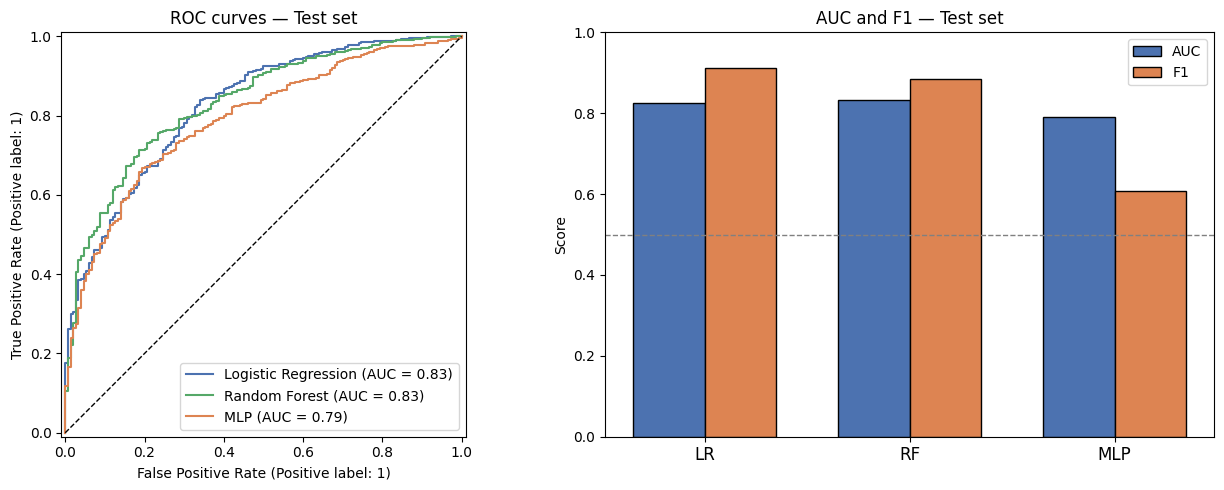

In [30]:
# ── 2.4  Compare all three models ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, probs, color in [
    ("Logistic Regression", lr_probs, "#4C72B0"),
    ("Random Forest",       rf_probs, "#55A868"),
    ("MLP",                 mlp_probs,"#DD8452"),
]:
    RocCurveDisplay.from_predictions(y_test, probs, name=name,
                                      ax=axes[0], color=color)
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_title("ROC curves — Test set")

# Bar chart: AUC / F1
models  = ["LR", "RF", "MLP"]
aucs = [roc_auc_score(y_test, p) for p in [lr_probs, rf_probs, mlp_probs]]
f1s  = [f1_score(y_test, p > .5)  for p in [lr_probs, rf_probs, mlp_probs]]

x = np.arange(len(models))
w = 0.35
axes[1].bar(x - w/2, aucs, w, label="AUC",  color="#4C72B0", edgecolor="black")
axes[1].bar(x + w/2, f1s,  w, label="F1",   color="#DD8452", edgecolor="black")
axes[1].set_xticks(x); axes[1].set_xticklabels(models, fontsize=12)
axes[1].set_ylim(0, 1); axes[1].set_ylabel("Score")
axes[1].set_title("AUC and F1 — Test set")
axes[1].legend(); axes[1].axhline(0.5, color="gray", lw=1, ls="--")

plt.tight_layout()
plt.show()
